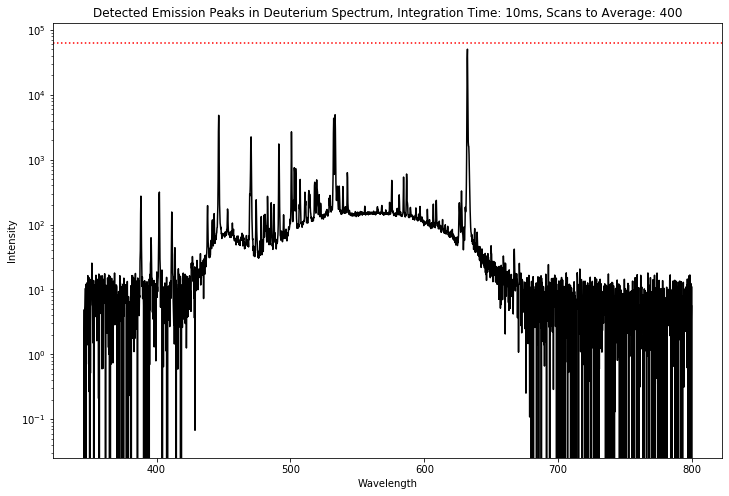

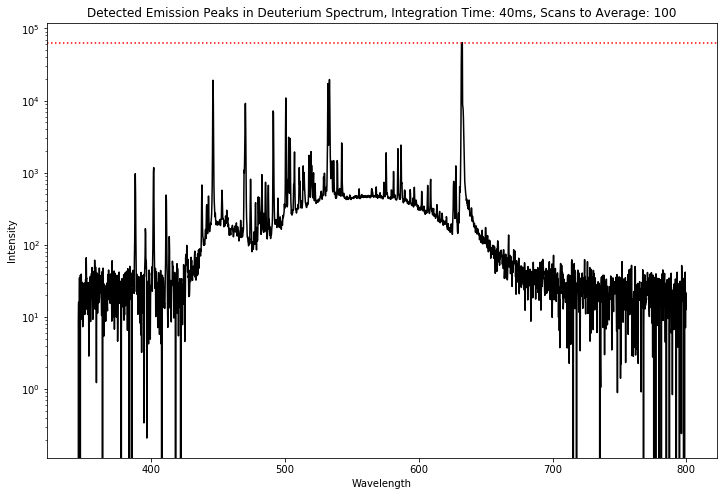

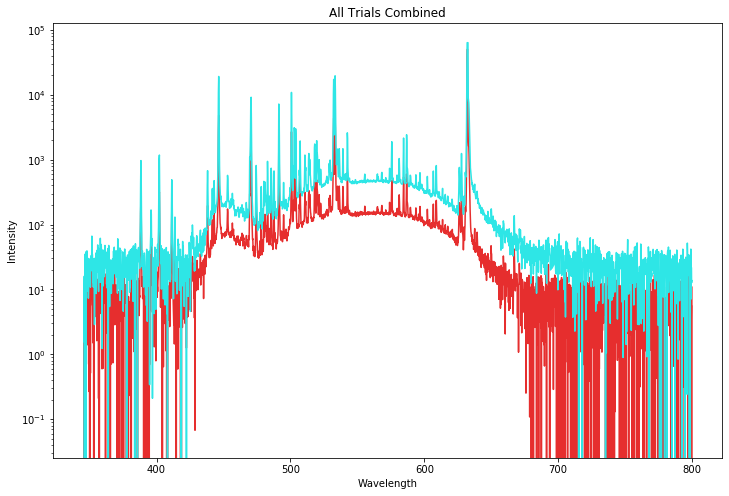

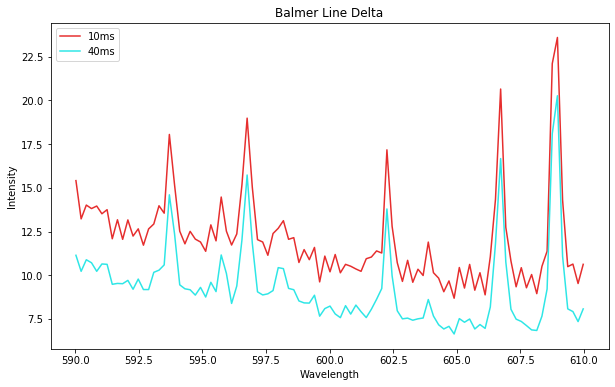

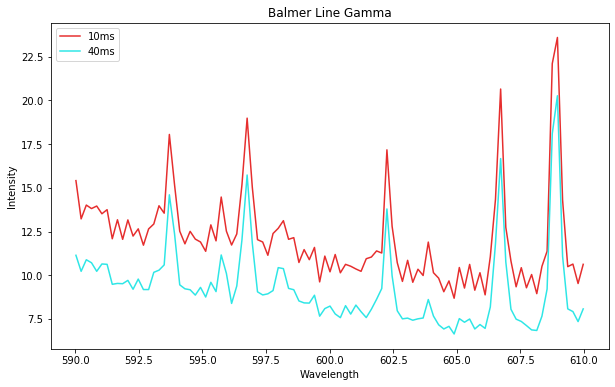

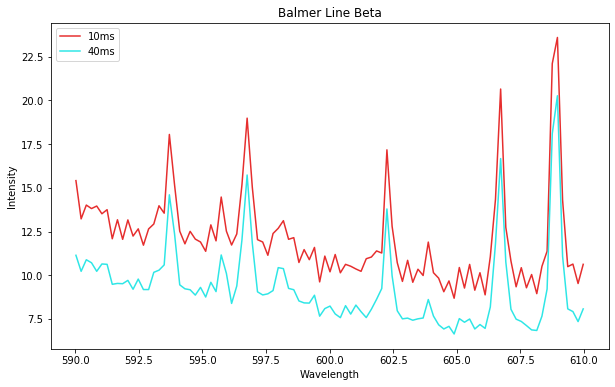

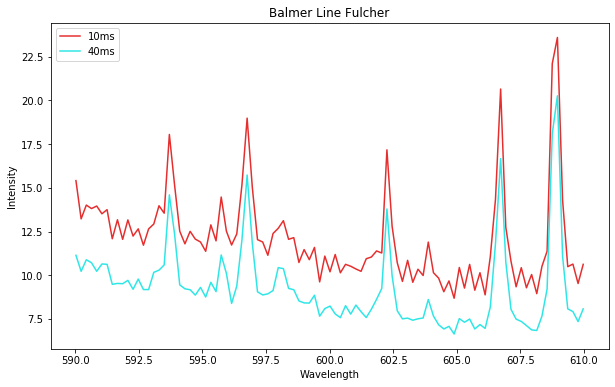

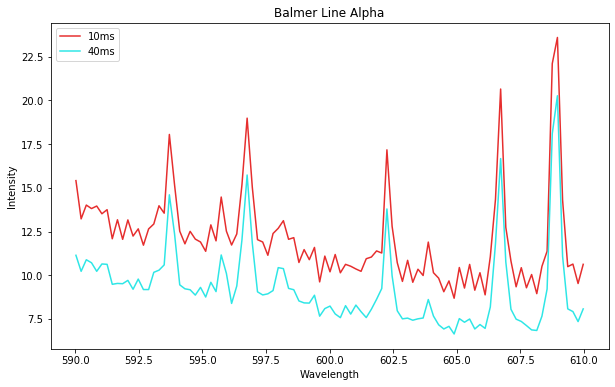

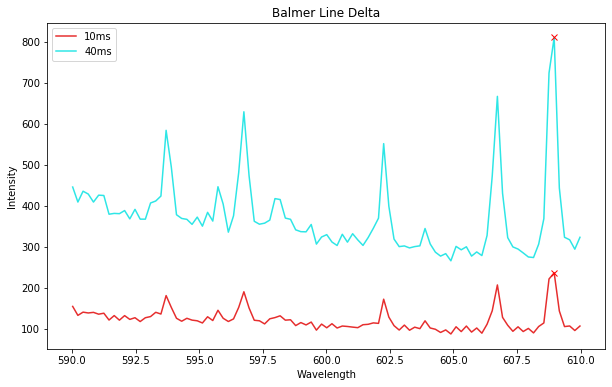

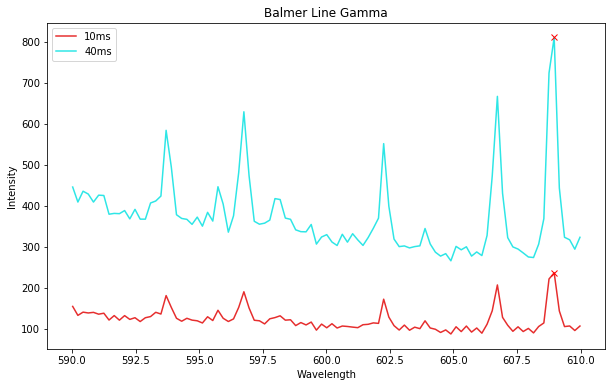

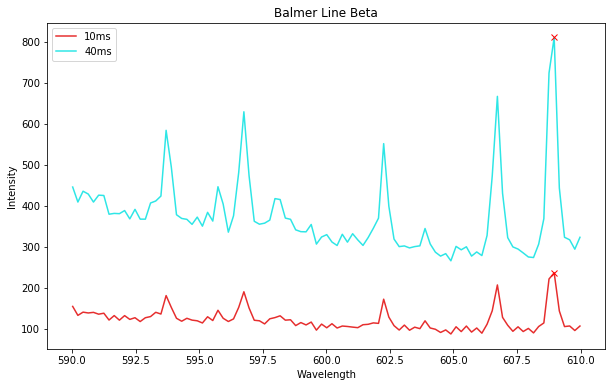

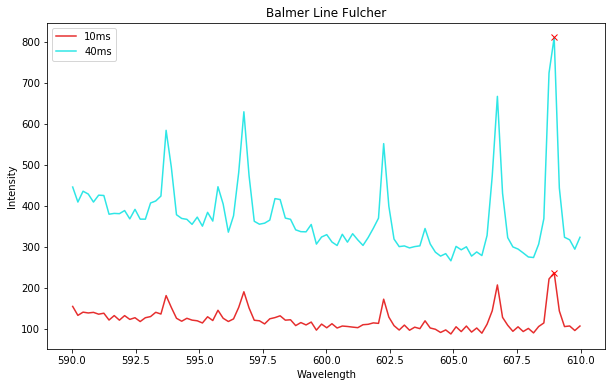

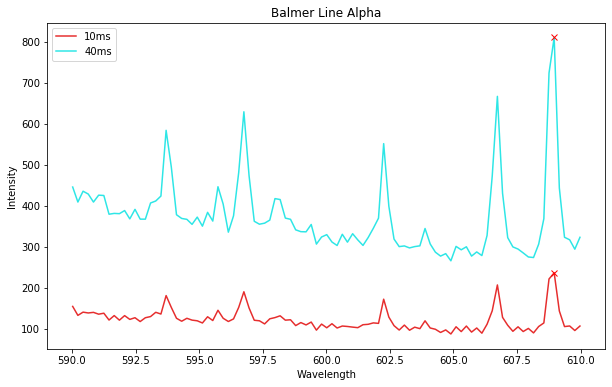

In [11]:
from pathlib import Path
import pandas as pd
from scipy.signal import find_peaks, peak_widths
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import colorsys
import os

# Dict of balmer lines and expected wavelengths
balmer_lines = {"Delta": 410, "Gamma": 434, "Beta": 486, "Fulcher": 590, "Alpha": 656}

def gauss(data, H, A, x0, sigma):
    return H + A * np.exp(-(data - x0) ** 2 / (2 * sigma ** 2))

def get_fit_errors(covariance_matrix):
    errors = []
    (num_parameters, _) = covariance_matrix.shape
    for i in range(num_parameters):
        errors.append(np.sqrt(np.diag(covariance_matrix))[i])
    return errors

def is_saturated(width_middle, width_top):
    if width_top / width_middle > 0.5:
        return True
    return False

class Trial:
    def __init__(self, file, saturation_line=None):
        self.file = file
        self.saturation_line = saturation_line
        self.integration_time, self.scans_to_average = self.parse_filename()
        self.data = self.read_data()
        self.peak_names, \
            self.peak_indices, \
            self.peak_wavelengths, \
            self.peak_intensities, \
            self.widths_middle, \
            self.widths_top, \
            self.saturated = self.find_peaks()
        
        self.H_params, \
            self.H_param_errors, \
            self.A_params, \
            self.A_param_errors, \
            self.x0_params, \
            self.x0_param_errors, \
            self.sigma_params, \
            self.sigma_param_errors = self.fit_all_balmer_lines()
        
    def parse_filename(self):
        parts = self.file.stem.split('_')
        assert len(parts) >= 8, "Found {} parts in the filename, should be at least 8".format(len(parts))
        assert parts[1][-2:] == "ms", "Integration time is in {}, should be in ms".format(parts[2][-2:])
        time = int(parts[1][:-2])
        return (time, parts[2])
        
    def read_data(self, skiprows=14):
        data = pd.read_csv(self.file.resolve(), skiprows=skiprows)
        data.columns = ['Wavelength', 'Intensity']
        return data

    def balmer_line_window(self, line, range_size):
        range_size = 20
        balmer_wavelength = 600
        half_range_size = range_size / 2
        #balmer_wavelength = balmer_lines[line]
        window_start = balmer_wavelength - half_range_size
        window_end = balmer_wavelength + half_range_size
        data_window = self.data.loc[(self.data['Wavelength'] >= window_start) & (self.data['Wavelength'] <= window_end)]
        return data_window

    def find_peaks(self):
        names = []
        indices = []
        wavelengths = []
        intensities = []
        widths_middle = []
        widths_top = []
        saturated = []
        for name, _ in balmer_lines.items():
            data_window = self.balmer_line_window(line=name, range_size=10)

            if data_window.empty:
                continue

            # Find the index with the max intensity, this is a peak
            peak_index = int(data_window['Intensity'].idxmax())
            peak_wavelength = data_window['Wavelength'][peak_index]
            peak_intensity = data_window['Intensity'][peak_index]
            assert peak_intensity == data_window['Intensity'].max(), "Indexmax should yield the max"
            
            width_middle = peak_widths(self.data['Intensity'], [peak_index], rel_height=0.5)[0][0]
            width_top = peak_widths(self.data['Intensity'], [peak_index], rel_height=0.05)[0][0]
            
            names.append(name)
            indices.append(peak_index)
            wavelengths.append(peak_wavelength)
            intensities.append(peak_intensity)
            widths_middle.append(width_middle)
            widths_top.append(width_top)
            saturated.append(is_saturated(width_middle, width_top))

        return (names, indices, wavelengths, intensities, widths_middle, widths_top, saturated)

    def graph_raw(self, balmer_labels=True):
        data_graph = self.data.loc[(self.data['Wavelength'] >= 0) & (self.data['Wavelength'] <= 800)]
        plt.figure(figsize=(12, 8))
        plt.title("Detected Emission Peaks in Deuterium Spectrum, Integration Time: {}ms, Scans to Average: {}".format(self.integration_time, self.scans_to_average))
        plt.plot(data_graph['Wavelength'], data_graph['Intensity'], label="Intensity vs. Wavelength", color="k")

        if self.saturation_line:
            plt.axhline(y=self.saturation_line, color='red', linestyle=':', linewidth=1.5)

        plt.xlabel('Wavelength')
        plt.ylabel('Intensity')
        plt.yscale('log')
        if balmer_labels:
            for i, (name, x, y) in enumerate(zip(self.peak_names, self.peak_wavelengths, self.peak_intensities)):
                color = 'red' if self.saturated[i] else 'blue'
                plt.plot(x, y, "x", color=color)
                plt.text(x, y, name, fontsize=12, ha='right', va='bottom')
                print("{}: wavelength: {}, peak intensity: {}".format(name, x, y))
                print("middle width: {}, top width: {}, saturated: {}".format(self.widths_middle[i], self.widths_top[i], self.saturated[i]))
        plt.show()
        
    def balmer_fit_window(self, line, range_size=40):
        try:
            peak_index = self.peak_names.index(line)
            half_range_size = range_size / 2
            start = int(self.peak_indices[peak_index] - half_range_size)
            end = int(self.peak_indices[peak_index] + half_range_size)
            return (start, end)
        except ValueError:
            print("No peak found for {}".format(line))
            return None
        
    def fit_balmer_line(self, line):
        try:
            peak_index = self.peak_names.index(line)
            guess = [0, self.peak_intensities[peak_index], self.peak_wavelengths[peak_index], 1]
            start, end = self.balmer_fit_window(line)
            res = curve_fit(gauss, self.data['Wavelength'][start:end], self.data['Intensity'][start:end], guess)
            (H, A, x0, sigma) = (res[0][0], res[0][1], res[0][2], res[0][3])
            (H_error, A_error, x0_error, sigma_error) = get_fit_errors(res[1])
            return (H, H_error, A, A_error, x0, x0_error, sigma, sigma_error)
        except ValueError:
            print("No peak found for {}".format(line))
            return None
        
    def fit_all_balmer_lines(self):
        H_params = []
        H_param_errors = []
        A_params = []
        A_param_errors = []
        x0_params = []
        x0_param_errors = []
        sigma_params = []
        sigma_param_errors = []
        for line in self.peak_names:
            (H, H_error, A, A_error, x0, x0_error, sigma, sigma_error) = self.fit_balmer_line(line)
            H_params.append(H)
            H_param_errors.append(H_error)
            A_params.append(A)
            A_param_errors.append(A_error)
            x0_params.append(x0)
            x0_param_errors.append(x0_error)
            sigma_params.append(sigma)
            sigma_param_errors.append(sigma_error)
            
        return (H_params, H_param_errors, A_params, A_param_errors, x0_params, x0_param_errors, sigma_params, sigma_param_errors)
        
    def plot_all_fits(self):
        for i, line in enumerate(self.peak_names):
            plt.figure(figsize=(10, 6))
            plt.title("Gaussian Fit for {}, Integration Time: {}ms, Scans to Average: {}".format(line, self.integration_time, self.scans_to_average))
            start, end = self.balmer_fit_window(line)
            plt.plot(self.data['Wavelength'][start:end], self.data['Intensity'][start:end], label="Intensity vs. Wavelength", color="k")
            plt.plot(self.data['Wavelength'][start:end], gauss(self.data['Wavelength'][start:end], self.H_params[i], self.A_params[i], self.x0_params[i], self.sigma_params[i]), label="Intensity Fit vs. Wavelength", color="#d534eb")
            plt.xlabel('Wavelength')
            plt.ylabel('Intensity')
            plt.legend()
            plt.grid(True)
            print("{} gaussian parameters: H = {}, A = {}, x0 = {}, sigma = {}\nerrors: {}, {}, {}, {}".format(line, self.H_params[i], self.A_params[i], self.x0_params[i], self.sigma_params[i], self.H_param_errors[i], self.A_param_errors[i], self.x0_param_errors[i], self.sigma_param_errors[i]))
            plt.show()
            
    def plot_sigma_vs_wavelength(self):
        plt.figure(figsize=(10, 6))
        plt.title("Gaussian Sigmas vs Wavelength for Integration Time: {}ms, Scans to Average: {}".format(self.integration_time, self.scans_to_average))
        plt.xlabel('Wavelength')
        plt.ylabel('Sigma with Error')
        for i, (name, x, y) in enumerate(zip(self.peak_names, self.x0_params, self.sigma_params)):
            color = 'red' if self.saturated[i] else 'blue'
            plt.errorbar(self.x0_params[i], self.sigma_params[i], yerr=self.sigma_param_errors[i], fmt='o', label="Errors", color=color)
            plt.text(x, y, name, fontsize=12, ha='right', va='bottom')
        plt.show()
            
        
class Experiment:
    def __init__(self, folder, saturation_line=None):
        self.folder = folder
        
        os.makedirs("{}_plots".format(self.folder), exist_ok=True)
        
        self.trials = []
        self.saturation_line = saturation_line
        for file in folder.iterdir():
            if file.is_file():
                trial = Trial(file, saturation_line)
                self.trials.append(trial)
        self.trials = sorted(self.trials, key=lambda t: t.integration_time)
        self.colors = self.get_colors()
                
    def graph_all(self):
        for t in self.trials:
            t.graph_raw(False)
            # t.plot_sigma_vs_wavelength()
            # t.plot_all_fits()
            
    def get_colors(self):
        num_colors = len(self.trials)
        return [colorsys.hsv_to_rgb(i / num_colors, 0.8, 0.9) for i in range(num_colors)]
    
    def graph_all_combined(self):
        plt.figure(figsize=(12, 8))
        title = "All Trials Combined"
        plt.title(title)
        plt.xlabel('Wavelength')
        plt.ylabel('Intensity')
        plt.yscale('log')
        
        for t, color in zip(self.trials, self.colors):
            data_graph = t.data.loc[(t.data['Wavelength'] >= 0) & (t.data['Wavelength'] <= 800)]
            plt.plot(data_graph['Wavelength'], data_graph['Intensity'], label="Intensity vs. Wavelength", color=color)
            
        plt.show()
            
    def graph_balmer_line_combined(self, balmer_line, range_size, normalized=False, trials=None):
        plt.figure(figsize=(10, 6))
        title = "Balmer Line {}".format(balmer_line)
        plt.title(title)
        plot_trials = self.trials
        if trials:
            plot_trials = [t for t in plot_trials if t.integration_time in trials]
        for t, color in zip(plot_trials, self.colors):
            balmer_range = t.balmer_line_window(balmer_line, range_size)
            if normalized:
                # Multiply all data by a scale factor that converts the current peak to
                # the height of the tallest peak
                peak = balmer_range['Intensity'].max()
                plt.plot(balmer_range['Wavelength'], balmer_range['Intensity'] / t.integration_time, label="{}ms".format(t.integration_time), color=color)
            else:
                plt.plot(balmer_range['Wavelength'], balmer_range['Intensity'], label="{}ms".format(t.integration_time), color=color)
            plt.xlabel('Wavelength')
            plt.ylabel('Intensity')
            if not normalized:
                try:
                    peak_index = t.peak_names.index(balmer_line)
                    plt.plot(t.peak_wavelengths[peak_index], t.peak_intensities[peak_index], "x", color="r")
                except ValueError:
                    print("No peak found for {}".format(balmer_line))
        plt.legend()
        plt.savefig("{}_plots/{}_{}{}.pdf".format(self.folder, title.replace(" ", "_"), "_".join(map(str, trials)) if trials else "all_trials", "_normalized" if normalized else ""))
        plt.show()
        
    def graph_all_balmer_lines_combined(self, range_size, normalized=False, trials=None):
        # Go through all balmer lines, and call graph_balmer_line_combined with each
        for line in balmer_lines:
            self.graph_balmer_line_combined(line, range_size, normalized, trials=trials)
            
    def graph_sigma_vs_integration_time(self, balmer_line):
        plt.figure(figsize=(10, 6))
        plt.title("Sigma vs Integration Times for {}".format(balmer_line))

        # Vertical line where alpha integrates
        if balmer_line == "Alpha":
            plt.axvline(x=130, color='red', linestyle=':', linewidth=1.5)

        for t in self.trials:
            try:
                peak_index = t.peak_names.index(balmer_line)
                color = 'red' if t.saturated[peak_index] else 'blue'
                plt.errorbar(t.integration_time, t.sigma_params[peak_index], yerr=t.sigma_param_errors[peak_index], fmt='o', color=color)
            except ValueError:
                print("No peak found for {}".format(balmer_line))
        plt.show()
    
    def graph_all_sigmas_vs_integration_times(self):
        # Go through all balmer lines, and call graph_sigma_vs_integration_time with each
        for line in balmer_lines:
            self.graph_sigma_vs_integration_time(line)
        

# Example file name: deutdg_200ms_20_SR4014911__0__16-45-59-520.csv,
# where 200 is integration time, 20 is scans to average
folder = Path("/home/crystal/research/deuterium_analysis/9_11_data/filter")
experiment = Experiment(folder=folder, saturation_line=63500)
experiment.graph_all()
experiment.graph_all_combined()
# experiment.graph_all_balmer_lines_combined(25)
experiment.graph_all_balmer_lines_combined(25, normalized=True)
experiment.graph_all_balmer_lines_combined(25, normalized=False)

# experiment.graph_all_balmer_lines_combined(25, normalized=True, trials=[4, 40, 80])
# experiment.graph_all_sigmas_vs_integration_times()